In [ ]:
# Add relevant Jupyter notebook cells below


In [16]:
# You can double-check your Python path like this...
import sys  
print(sys.path)

['c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25', 'C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25\\venv', '', 'c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25\\venv\\Lib\\site-packages', 'c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25']


# Simulate closed-loop
After implementing your control functionality, you can simulate the closed-loop with code that looks something like this...

In [17]:
# Test file loading
import pandas as pd
df = pd.read_csv("../data/mission.csv")  # Note the ../
print(df.head())
print(df.columns)

   reference  cave_height  cave_depth
0   0.000000    30.000000  -30.000000
1   2.923913    29.161276  -18.133231
2   5.514324    27.954324   -8.659243
3   7.487585    31.848083  -10.294475
4   8.652029    29.378185   -2.496739
Index(['reference', 'cave_height', 'cave_depth'], dtype='object')


In [18]:
import os, sys
from pathlib import Path

print("cwd:", os.getcwd())
print("python executable:", sys.executable)
print("first 10 sys.path entries:")
for p in sys.path[:10]:
    print("  ", p)
print("files in cwd:", os.listdir('.'))
print("uuv_mission exists in cwd?:", Path('uuv_mission').exists())


cwd: c:\Users\jonjo\OneDrive\Documents\GitHub\b1-coding-practical-mt25\notebooks
python executable: c:\Users\jonjo\OneDrive\Documents\GitHub\b1-coding-practical-mt25\venv\Scripts\python.exe
first 10 sys.path entries:
   c:\Users\jonjo\OneDrive\Documents\GitHub\b1-coding-practical-mt25
   C:\Users\jonjo\AppData\Local\Programs\Python\Python312\python312.zip
   C:\Users\jonjo\AppData\Local\Programs\Python\Python312\DLLs
   C:\Users\jonjo\AppData\Local\Programs\Python\Python312\Lib
   C:\Users\jonjo\AppData\Local\Programs\Python\Python312
   c:\Users\jonjo\OneDrive\Documents\GitHub\b1-coding-practical-mt25\venv
   
   c:\Users\jonjo\OneDrive\Documents\GitHub\b1-coding-practical-mt25\venv\Lib\site-packages
   c:\Users\jonjo\OneDrive\Documents\GitHub\b1-coding-practical-mt25
files in cwd: ['demo.ipynb']
uuv_mission exists in cwd?: False


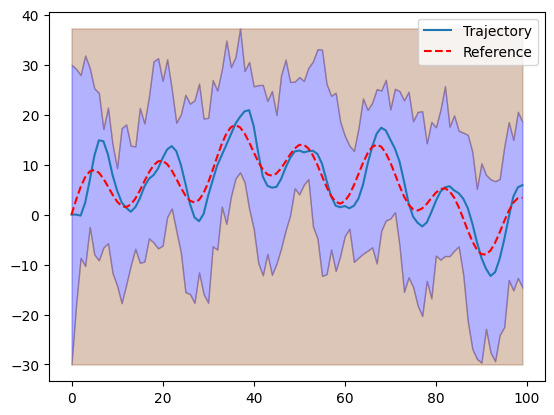

In [19]:
# Import relevant modules
import sys, os
sys.path.append(os.path.abspath(".."))  # add parent dir

import numpy as np
import matplotlib.pyplot as plt
from uuv_mission.dynamic import Mission
from uuv_mission.dynamic import Submarine, ClosedLoop
from uuv_mission.controller import PDController

sub = Submarine()
controller = PDController(kp = 0.15, kd = 0.6)

closed_loop = ClosedLoop(sub, controller)
mission = Mission.from_csv("../data/mission.csv")

trajectory = closed_loop.simulate_with_random_disturbances(mission)
trajectory.plot_completed_mission(mission)